# PCA Neural Trajectories on PhysioNet EEGBCI

This is a companion tutorial to the paper *“A Primer on Low-Dimensional Neural Dynamics: PCA-Based Trajectory Analysis for EEG and MEG.”* 

In this notebook, we walk through the **10-step PCA trajectory workflow** outlined in the paper. We apply it to a small slice (5 subjects) of the PhysioNet EEGBCI motor imagery dataset, ultimately showing how to export your results to an interactive HTML report.

<div class="alert alert-secondary">
<b>🗺️ Tutorial Series Roadmap:</b><br>
This notebook is the foundation of a broader series:
<ol style="margin-bottom: 0; margin-top: 5px;">
    <li><b>Introductory Tutorial (This Notebook):</b> Core 10-step PCA workflow.</li>
    <li><b>Advanced Tutorial:</b> Deep dive into advanced trajectory metrics and analysis.</li>
    <li><b>Decoding Tutorial:</b> Using trajectories for Brain-Computer Interface (BCI) decoding.</li>
    <li><b>MEG Faces Tutorial:</b> Applying these methods to MEG visual processing data.</li>
</ol>
</div>

### Dataset & Expected Outputs

- **Dataset:** PhysioNet EEGBCI. We use 5 subjects here. *(Note: The full 109-subject analysis can be found in `analysis/analysis_paper_eegbci_109.py`)*.
- **Conditions:** 4 conditions (Left Hand / Right Hand Execution, Both Hands / Both Feet Execution).

**Outputs Generated by this Notebook:**
- `outputs/tutorial_eegbci/report_tutorial_eegbci.html` — The standalone interactive HTML dashboard.
- `outputs/tutorial_eegbci/figures/*.svg` — High-resolution static figures in SVG format.
- `outputs/tutorial_eegbci/artifacts/` — Saved PCA models and metadata required for the advanced tutorials.


## 0. Setup & Configuration

This section configures the local environment, imports `coco-pipe`, and establishes the global parameters, color palettes, and file paths we will use throughout the tutorial.

### 0.1. Environment & Imports

To run this tutorial, you need two main libraries: `coco-pipe` and `mne`. 

<div class="alert alert-info">
<b>💻 Installation:</b><br>
We recommend using <a href="https://github.com/astral-sh/uv">uv</a> (or pip) to install the package and its dependencies in a clean virtual environment:
<pre style="margin-top: 10px; background-color: rgba(255, 255, 255, 0.7); border-radius: 4px; padding: 10px;"><code>uv pip install coco-pipe mne</code></pre>
</div>

In [3]:
# Now we can import the required libraries
import mne
import coco_pipe
# import tutorials._helpers as helpers
print(f"Using coco_pipe version: {getattr(coco_pipe, "__version__", "(dev)")}")
print(f"Using MNE version: {mne.__version__}")

Using coco_pipe version: (dev)
Using MNE version: 1.12.1


In [4]:
import sys
from pathlib import Path

# Ensure the project root (one level above this notebook) is on sys.path
# so that ``import tutorials._helpers`` works whether the notebook is
# launched from the project root or from inside ``tutorials/``.
_PROJECT_ROOT = Path.cwd()
if (_PROJECT_ROOT / 'coco_pipe').is_dir() is False and (_PROJECT_ROOT.parent / 'coco_pipe').is_dir():
    _PROJECT_ROOT = _PROJECT_ROOT.parent
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

In [10]:
# --- Standard Library & Core DS ---
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import matplotlib as mpl

# --- coco-pipe: Core Data Structures ---
# DataContainer handles stacking MNE Epochs into (n_trials, n_channels, n_times) arrays
# BIDSDataset handles automated parsing and loading of BIDS directories
from coco_pipe.io.structures import DataContainer
from coco_pipe.io.dataset import BIDSDataset

# --- coco-pipe: Dimensionality Reduction & Metrics ---
# DimReduction: The core class for fitting PCA and transforming trajectories
# trajectory_*: The atomic metrics for measuring kinematics (from Table 2 of the paper)
from coco_pipe.dim_reduction import (
    DimReduction,
    apply_pca_score_baseline,       # Baselines the PCA scores (usually at stimulus onset)
    flip_pc_scores_for_consistency, # Ensures PC sign/polarity is consistent across subjects
    grouped_condition_stats,        # Extracts condition-level statistics 
    paired_condition_stats,         # Extracts statistics for comparing condition pairs
    trajectory_curvature,
    trajectory_dispersion,
    trajectory_intra_spread,
    trajectory_path_length,
    trajectory_separation,
    trajectory_speed,
)

# --- coco-pipe: Interactive Visualization ---
# A suite of Plotly-based interactive dashboards for exploring neural trajectories
from coco_pipe.viz.interactive import (
    plot_bar,
    plot_channel_traces,
    plot_component_loadings,
    plot_distribution_groups,
    plot_eigenvalues,
    plot_embedding,                   # Interactive 3D trajectory visualization
    plot_heatmap,
    plot_null_interval_summary,
    plot_shepard_diagram,
    plot_trajectory,                  # 2D/3D single or averaged trajectories
    plot_trajectory_metric_series,    # Time-series of metrics (e.g., speed over time)
    plot_trajectory_separation,       # Distance between conditions over time
)

# --- Local Tutorial Helpers ---
# Functions for downloading BIDS data and iterating the metric computations over trials
from tutorials._helpers import (
    compute_per_condition_scalars,
    compute_per_trial_scalars,
    compute_separation_pair_scalars,
    compute_separation_timecourses,
    make_trial_meta,
    permutation_null_separation_auc,
    save_artifacts,
    setup_data_bids,
)


### 0.2. Visual Theme & Condition Metadata

<div class="alert alert-success">
<b>🎨 Publication-Ready & Accessible Plots:</b><br>
<code>coco-pipe</code> provides a built-in theming engine (<code>coco_pipe.viz.theme</code>) designed to generate highly accessible figures out of the box. We activate it here globally, forcing the <b>colorblind-friendly</b> palette for all outputs.
</div>

Additionally, the raw PhysioNet EEGBCI dataset uses integer labels for events. We explicitly define our target experimental conditions below and map them directly to the `coco-pipe` colorblind palette. This ensures absolute color consistency across all our interactive dashboards and static plots.


In [11]:
import numpy as np
import matplotlib as mpl
from coco_pipe.viz.theme import set_coco_theme

# ---------------------------------------------------------------------------
# 1. Global Visual Theme
# ---------------------------------------------------------------------------
# coco-pipe provides an accessible, publication-ready theming engine.
set_coco_theme(mode="paper", colorblind=True)
coco_colors = mpl.rcParams["axes.prop_cycle"].by_key()["color"]

# ---------------------------------------------------------------------------
# 2. EEGBCI Condition Metadata
# ---------------------------------------------------------------------------
# The PhysioNet EEGBCI dataset uses integer labels for events. 
# We define all available conditions and map them to readable names.

LABEL_INFO = {
    3: {"name": "Left Hand (Exec)", "mode": "exec", "effector": "left_hand", "laterality": "unilateral"},
    4: {"name": "Right Hand (Exec)", "mode": "exec", "effector": "right_hand", "laterality": "unilateral"},
    5: {"name": "Left Hand (Imag)", "mode": "imag", "effector": "left_hand", "laterality": "unilateral"},
    6: {"name": "Right Hand (Imag)", "mode": "imag", "effector": "right_hand", "laterality": "unilateral"},
    7: {"name": "Hands (Exec)", "mode": "exec", "effector": "hands", "laterality": "bilateral"},
    8: {"name": "Feet (Exec)", "mode": "exec", "effector": "feet", "laterality": "bilateral"},
    9: {"name": "Hands (Imag)", "mode": "imag", "effector": "hands", "laterality": "bilateral"},
    10: {"name": "Feet (Imag)", "mode": "imag", "effector": "feet", "laterality": "bilateral"},
}

LABEL_NAMES = {k: v["name"] for k, v in LABEL_INFO.items()}

# In this tutorial, we analyze the 4 physical "execution" tasks.
DEFAULT_CONDITIONS = (3, 4, 7, 8)

# --- Alternative analyses you can try ---
# To generate the same figures for different cognitive dynamics, 
# simply uncomment one of the following lines and re-run the notebook:
#
# DEFAULT_CONDITIONS = (5, 6, 9, 10)  # Pure Imagination (Hands & Feet)
# DEFAULT_CONDITIONS = (3, 4, 5, 6)   # Execution vs. Imagination (Left/Right Hand only)

# DEFAULT_CONDITIONS = (...) # you can create your own set of conditions. 

# ---------------------------------------------------------------------------
# 3. Color Mapping
# ---------------------------------------------------------------------------
# We map every possible condition to the 8-color colorblind cycle so users 
# can safely change DEFAULT_CONDITIONS without breaking the plots.

CONDITION_COLORS = {
    # --- Execution Tasks ---
    3: coco_colors[0],  # Blue
    4: coco_colors[1],  # Vermilion
    7: coco_colors[2],  # Bluish Green
    8: coco_colors[3],  # Reddish Purple
    
    # --- Imagination Tasks ---
    5: coco_colors[4],  # Yellow
    6: coco_colors[5],  # Sky Blue
    9: coco_colors[6],  # Orange
    10: coco_colors[7], # Black
}

### 0.3. Analysis Parameters & Paths

Finally, we set the parameters for our analysis and create the output directories where our generated artifacts and figures will be saved. 

<div class="alert alert-warning">
<b>🧠 Methodological Note (Time Windows):</b><br> 
We load very broad epochs (<code>-1.0s</code> to <code>3.0s</code>) from the raw MNE data to prevent filter edge artifacts from corrupting our signals. However, the PCA model itself will <i>only</i> be fit on the specific <code>ANALYSIS_TMIN</code> to <code>ANALYSIS_TMAX</code> task window to ensure it exclusively captures task-related variance!
</div>


In [12]:
from pathlib import Path

# ---------------------------------------------------------------------------
# 1. Global Analysis Parameters
# ---------------------------------------------------------------------------
rng = np.random.default_rng(42)

# We use 5 subjects for a fast tutorial (the full paper script uses 109)
SUBJECTS = list(range(1, 6))  
N_COMPONENTS = 10

# The specific time window (in seconds) over which we will fit the PCA.
ANALYSIS_TMIN = 0.0
ANALYSIS_TMAX = 1.0

# The wider window we will use for transforming and plotting.
PLOT_TMIN = -0.2

# ---------------------------------------------------------------------------
# 2. File Paths & Directories
# ---------------------------------------------------------------------------
# Where we expect the downloaded raw BIDS data to live
BIDS_DIR = Path('PhysioNet_EEGBCI/BIDS')

# Where we will save our final tutorial outputs (SVGs, Reducers, CSVs)
ROOT = Path('outputs/tutorial_eegbci')
ARTIFACTS_DIR = ROOT / 'artifacts'

# Ensure the output directories exist before we start saving things to them
ROOT.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)


## Step 2. Preprocess & Normalize Data
*(Paper Figure 1, Step 2)*

<div class="alert alert-warning">
<b>⚠️ Why preprocessing is critical for PCA:</b><br>
PCA does not know what is "neural signal" and what is "noise"—it simply finds the directions of maximum variance. If you don't remove eye blinks and heartbeats, those huge artifacts will completely dominate Principal Component 1!
</div>

Before extracting neural trajectories, raw EEG data must be cleaned and epoched. To keep this notebook focused on PCA dynamics, we split this into three phases:

<span style="color: #0072B2;"><b>Phase 1: Download & Preprocess (MNE-Python)</b></span><br>
We use a helper function `setup_data_bids` to execute a state-of-the-art MNE preprocessing pipeline before writing the epoched data to a standardized BIDS directory. It automatically applies:
1. <span style="color: #D55E00;"><b>Bandpass filter:</b></span> 0.5–40 Hz (FIR). *(Note: The 40Hz lowpass naturally suppresses most broadband muscle artifacts).*
2. <span style="color: #D55E00;"><b>Notch filter:</b></span> 50/60 Hz to remove residual line noise.
3. <span style="color: #D55E00;"><b>Eye and Heart Artifact Removal:</b></span> Fits a 20-component ICA and uses the `mne-icalabel` neural network to automatically identify and subtract **blinks** and **heartbeats** (ECG artifacts). 

<span style="color: #0072B2;"><b>Phase 2: Load into coco-pipe</b></span><br>
Once the BIDS directory is populated, we use `coco-pipe`'s native `BIDSDataset` API to load the epoched data into a `DataContainer`. 

<span style="color: #0072B2;"><b>Phase 3: Crop, Baseline, and Normalize (Z-score)</b></span><br>
First, we crop the data to a generous plotting window (`-0.2s` to `1.0s`) and apply a per-channel baseline correction to remove any raw sensor drift. Next, we apply per-channel z-scoring across observations to prevent the PCA from being dominated by a few high-amplitude sensors. Finally, we extract a strict task-only subset (`0.0s` to `1.0s`) that will be used purely to fit the PCA model.


In [13]:
# ==============================================================================
# PHASE 1: Download raw data, preprocess with MNE, and save to BIDS format
# ==============================================================================
# (This step might take a minute or two if the data isn't cached!)
setup_data_bids(
    subjects=SUBJECTS, 
    runs=list(range(3, 15)), 
    root=BIDS_DIR
)
print(f"Preprocessed BIDS data is ready at: {BIDS_DIR}\n")

# ==============================================================================
# PHASE 2: Load the preprocessed BIDS data into a coco-pipe DataContainer
# ==============================================================================
filtered_events = {k: v for k, v in LABEL_INFO.items() if k in DEFAULT_CONDITIONS}
event_id_dict = {f"{v['effector']}_{v['mode']}": k for k, v in filtered_events.items()}

ds = BIDSDataset(
    root=str(BIDS_DIR),
    task="motorimagery",
    datatype="eeg",
    mode="epochs",
    event_id=event_id_dict,
    runs=[f"{r:02d}" for r in range(3, 15)],
    tmin=ANALYSIS_TMIN - 1.0, 
    tmax=ANALYSIS_TMAX + 1.5,
    baseline=(-1.0, 0.0),
)

container = ds.load()
times = np.asarray(container.coords['time'])
channels = np.asarray(container.coords['channel'])
subject_ids = np.asarray(container.coords['subject'])
print(f"Loaded 3D Tensor Shape: {container.X.shape}")


EEGBCI: subjects=[1, 2, 3, 4, 5], runs=[3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14], root=PhysioNet_EEGBCI/BIDS
EEGBCI BIDS root: PhysioNet_EEGBCI/BIDS
Preprocessed BIDS data is ready at: PhysioNet_EEGBCI/BIDS

Reading 0 ... 19999  =      0.000 ...   124.994 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(

In [14]:
# ==============================================================================
# PHASE 3: Crop to the PLOT window, chain baseline + zscore, then subset for FIT
# ==============================================================================
# 1. Crop to the wider plotting window (-0.2 to 1.0s)
plot_mask = (times >= PLOT_TMIN - 1e-8) & (times <= ANALYSIS_TMAX + 1e-8)

# DataContainer methods return new containers, so they compose cleanly!
container_plot = (
    container
    .isel(time=plot_mask)
    .baseline_correction(dim='time')
    .zscore(dim='obs', eps=1e-5)
)

# 2. Extract the strict task subset for PCA fitting (0.0 to 1.0s)
fit_mask = (container_plot.coords['time'] >= ANALYSIS_TMIN - 1e-8)
container_fit = container_plot.isel(time=fit_mask)

# Extract the final metadata (we'll keep track of the wider plotting time axis!)
times_win = np.asarray(container_plot.coords['time'])
labels_win = np.asarray(container_plot.y).astype(int)

print(f"Shape for Plotting (-0.2 to 1.0s): {container_plot.X.shape}")
print(f"Shape for Fitting  ( 0.0 to 1.0s): {container_fit.X.shape}")


Shape for Plotting (-0.2 to 1.0s): (450, 64, 193)
Shape for Fitting  ( 0.0 to 1.0s): (450, 64, 161)


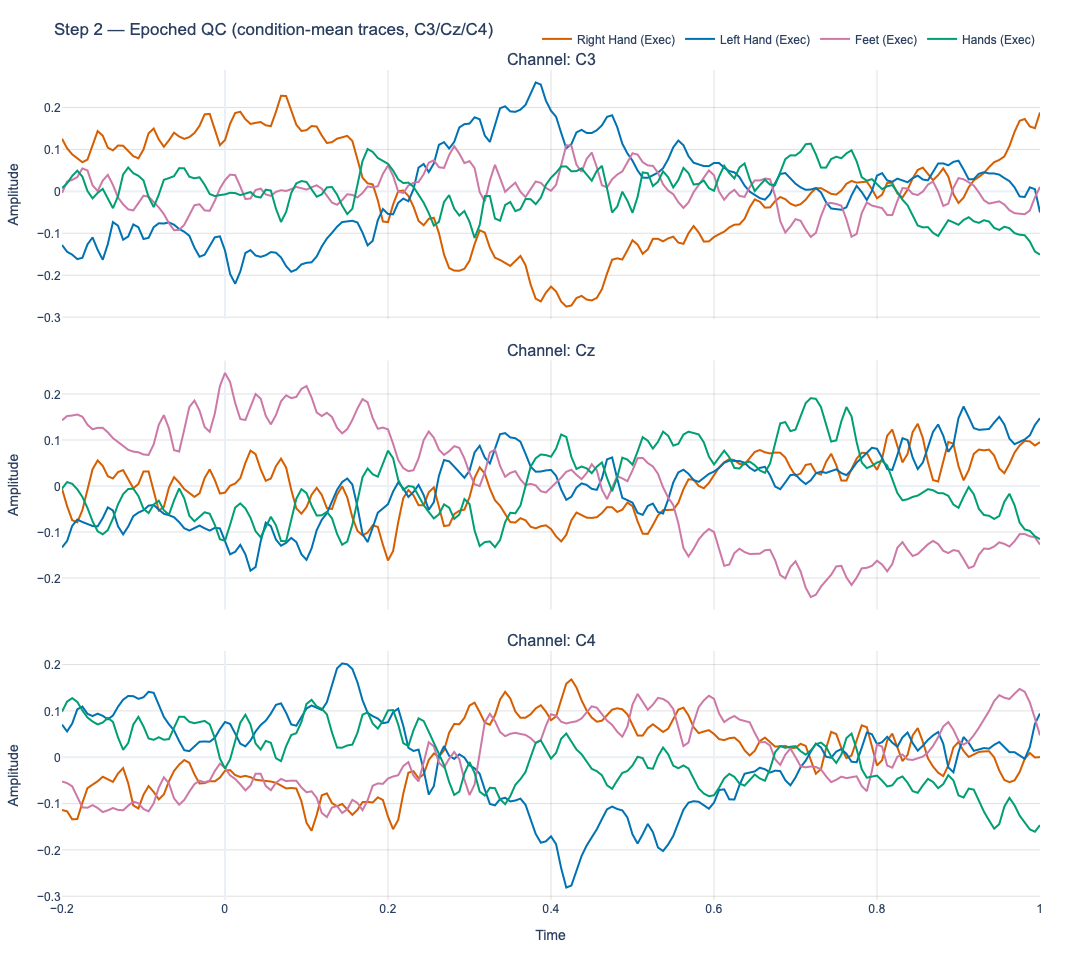

In [15]:
# ==============================================================================
# QUALITY CONTROL: Plot condition-mean traces over motor channels
# ==============================================================================
# We aggregate the trials by condition to generate Event-Related Potentials (ERPs)
# Make sure to use container_plot, which includes our pre-stimulus baseline!
container_for_qc = container_plot.aggregate(by='y', stats='mean')

# We only want to plot the central motor channels to verify our motor imagery paradigm
preferred = ['C3', 'Cz', 'C4']
selected = [c for c in preferred if c in channels]

fig_qc = plot_channel_traces(
    data=container_for_qc.X,
    times=np.asarray(container_for_qc.coords['time']),
    group_labels=np.asarray(container_for_qc.coords['obs']).astype(int),
    channel_names=np.asarray(container_for_qc.coords['channel']).astype(str),
    selected_channels=selected,
    group_name_map=LABEL_NAMES,
    color_map=CONDITION_COLORS,
    title='Step 2 — Epoched QC (condition-mean traces, C3/Cz/C4)',
)
fig_qc.show()


## Step 3. Reshape into (Samples × Features)
To apply PCA, our 3-dimensional neural data must be carefully reshaped into a flat 2-dimensional matrix. To align with the theory from your paper, we make two crucial methodological choices here:

* <span style="color: #D55E00;"><b>Single-Trial Preservation:</b></span> To capture true biological variance, we do *not* average trials before PCA. We treat every single timepoint of every trial as a separate independent observation. 
* <span style="color: #D55E00;"><b>Subject Normalization:</b></span> Unaligned group-level PCA can be dominated by idiosyncratic subject differences. We mitigate this by exploring two types of models: a *Shared PCA* (all subjects pooled) and *Per-Subject PCAs*.

Recall from <a href="#1.-Choose-your-representation">Step 1</a> that we defined our neural state as a spatial pattern: $\mathbf{x}(t) \in \mathbb{R}^{64}$. 

<div class="alert alert-info" style="margin-top: 15px;">
<b>📦 The Tensor Flattening Math:</b><br>
When loaded, our data is a 3D tensor: <code>[Total Trials (T), Channels (C), Time (N)]</code>. <br>
<i>(Note: For simplification, the Subject dimension is absorbed into T. Specifically, <b>T = N<sub>trials per subject</sub> &times; N<sub>subjects</sub></b>!)</i><br><br>
To discover spatial topographies, we use <code>DataContainer.stack()</code> to flatten this into <code>[(T &times; N) Observations, C Features]</code>. Because <code>coco-pipe</code> tracks the metadata expansion, we can cleanly <code>unstack()</code> our 2D PCA scores back into 3D trajectories later!
</div>

Below, we stack the data **twice**: once on the pooled multi-subject container (for Step 4a), and once for each individual subject (for Step 4b).


In [17]:
# ==============================================================================
# 1. Pooled stacks → inputs to Shared PCA (Step 4a)
# ==============================================================================
# We stack 'obs' (trials) and 'time' into a single long observation dimension

# The FITTING container (strict task window)
container_fit_pooled = container_fit.stack(dims=('obs', 'time'), new_dim='obs')
print(f"Fit stacked shape (obs*time, channel): {container_fit_pooled.X.shape}")

# The PLOTTING container (includes pre-stimulus baseline)
container_plot_pooled = container_plot.stack(dims=('obs', 'time'), new_dim='obs')
print(f"Plot stacked shape (obs*time, channel): {container_plot_pooled.X.shape}")

# ==============================================================================
# 2. Per-subject stacks → input to per-subject PCAs (Step 4b)
# ==============================================================================
# We keep these in a dictionary to fit individual models in the next step.
# NOTE: We only need the FIT window here, as per-subject PCAs are only used 
# for scalar validation metrics (Step 9) which focus entirely on the task period!
per_subject_fit_stacks: dict = {}

for sub_id in np.unique(subject_ids):
    sub_mask = subject_ids == sub_id
    container_sub = container_fit.isel(obs=sub_mask)
    
    per_subject_fit_stacks[sub_id] = container_sub.stack(
        dims=('obs', 'time'), new_dim='obs'
    )

print("Per-subject stacked shapes:", {k: v.X.shape for k, v in per_subject_fit_stacks.items()})


Fit stacked shape (obs*time, channel): (72450, 64)
Plot stacked shape (obs*time, channel): (86850, 64)
Per-subject stacked shapes: {np.str_('001'): (14490, 64), np.str_('002'): (14490, 64), np.str_('003'): (14490, 64), np.str_('004'): (14490, 64), np.str_('005'): (14490, 64)}


## Step 4. Fit the PCA Models

Because we are dealing with multiple subjects, we must be very careful about group-level alignment. We solve this by fitting **two different types of PCA models**:

#### 4a. Shared PCA (For Group-Level Figures)
We fit one global PCA on the **pooled** subject data. Every group-mean trajectory figure we generate later will live in this shared basis space. This ensures that when we look at the 3D plots, the spatial topographies mean the same thing across all subjects.

#### 4b. Per-Subject PCA (For Scalar Statistics)
We fit a separate PCA for each individual subject. We use these *per-subject* scores exclusively to compute our scalar kinematics (like trajectory speed and path length), ensuring our statistics capture true, honest within-subject variance.

<div class="alert alert-warning">
<b>⚠️ The Group-Level Alignment Caveat:</b><br>
Why don't we just use the per-subject PCAs for the 3D figures? Because Subject 1's "PC1" is not necessarily the same spatial direction as Subject 2's "PC1"—components can swap order or rotate based on individual head shapes! We use the <code>flip_pc_scores_for_consistency</code> function in Step 6 to fix <i>sign</i> flips, but it cannot fix component swaps. This is why we must maintain both a Shared PCA (for plotting) and Per-Subject PCAs (for statistics).
</div>


In [18]:
# ==============================================================================
# Step 4a: Shared PCA
# ==============================================================================
shared_reducer = DimReduction(
    method='PCA',
    n_components=N_COMPONENTS,
    random_state=42,
)

# 1. FIT strictly on the task window (0.0 to 1.0s)
shared_reducer.fit(container_fit_pooled.X)

# 2. TRANSFORM the wider plotting window (-0.2 to 1.0s)
shared_scores = shared_reducer.transform(container_plot_pooled.X)

print(f"Shared embedding shape (includes pre-stimulus!): {shared_scores.shape}")

evr = shared_reducer.get_diagnostics().get('explained_variance_ratio_')
if evr is not None:
    print(f"Shared PCA cumulative variance @ 3 / 5 / 10 PCs: "
          f"{np.sum(evr[:3]):.2f} / {np.sum(evr[:5]):.2f} / {np.sum(evr):.2f}")

# ==============================================================================
# Step 4b: Per-subject PCA
# ==============================================================================
per_subject_reducers: dict = {}
per_subject_scores: dict = {}

# We iterate over our fit-only dictionary, since scalar metrics don't need the baseline!
for sub_id, stack in per_subject_fit_stacks.items():
    reducer = DimReduction(
        method='PCA', 
        n_components=N_COMPONENTS, 
        random_state=42
    )
    # Fit and transform the strict task window
    per_subject_scores[sub_id] = reducer.fit_transform(stack.X)
    per_subject_reducers[sub_id] = reducer

print(f"\nSuccessfully fit separate PCAs for {len(per_subject_reducers)} subjects.")

Shared embedding shape (includes pre-stimulus!): (86850, 10)
Shared PCA cumulative variance @ 3 / 5 / 10 PCs: 0.71 / 0.79 / 0.86

Successfully fit separate PCAs for 5 subjects.


## Step 5. Select Components

How many Principal Components do we actually need? To visualize the neural dynamics **2–3 PCs typically suffice** for trajectory visualization in EEG/MEG.

We evaluate this using two methods:
1. <span style="color: #D55E00;"><b>Scree Plot:</b></span> A visual plot of the Explained Variance Ratio (EVR) per component.
2. <span style="color: #D55E00;"><b>Participation Ratio (PR):</b></span> A robust mathematical metric that gives us a single number representing the "effective dimensionality" of the dataset.

<div class="alert alert-info" style="margin-top: 15px;">
<b>🧠 What is the Participation Ratio?</b><br>
Unlike simply picking an arbitrary variance cutoff (e.g., "keep PCs until 80% variance is reached"), the Participation Ratio mathematically quantifies how many dimensions the neural data is <i>actually</i> using. If your PR is 2.4, it means your complex 64-channel neural trajectories are effectively living in a 2.4-dimensional space!
</div>

*(Note: We fit 10 components globally so that advanced users can use them later, but our downstream 3D visualizations will only utilize the top 3.)*


Cumulative variance at 3 PCs: 71.30%
Participation ratio (effective dimensionality): 2.45



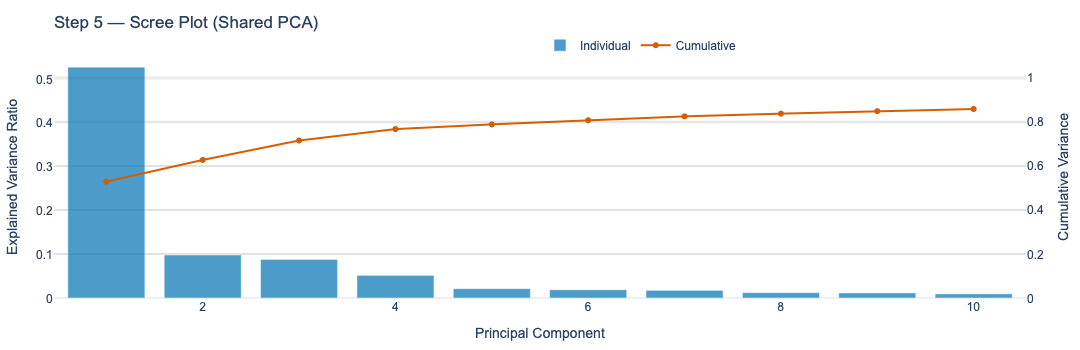

In [19]:
# Ensure we have the EVR array from Step 4a
evr_array = np.asarray(evr)

# ==============================================================================
# 1. Mathematical Metrics
# ==============================================================================
# Retrieve the Participation Ratio natively from the coco-pipe reducer!
pr = shared_reducer.get_diagnostics().get('participation_ratio_')

print(f"Cumulative variance at 3 PCs: {np.sum(evr_array[:3]):.2%}")
if pr is not None:
    print(f"Participation ratio (effective dimensionality): {pr:.2f}\n")

# ==============================================================================
# 2. Scree Plot
# ==============================================================================
fig_scree = plot_eigenvalues(evr_array)
fig_scree.update_layout(title='Step 5 — Scree Plot (Shared PCA)')

# Render the interactive Plotly figure directly in the notebook!
fig_scree.show()


## Step 6. Project, unstack, baseline, and align signs

Now that our PCA basis is defined, we must project our flattened, 2-dimensional data back into its original biological structure `(trials × time × components)`. We accomplish this by mapping the PCA scores back onto our `DataContainer` via `with_features`, and then calling `unstack()` to reverse the matrix reshaping we performed in [Step 3](#Step-3.-Reshape-the-dataset).

Before we can safely plot these trajectories, we must apply two critical post-processing corrections to the PC-space data:

<div class="alert alert-warning">
<b>⚠️ Why do we need post-processing in PC-space?</b><br>
PCA is a purely mathematical rotation. It does not guarantee that your neural trajectories will start at the origin $(0, 0, 0)$, nor does it guarantee that the eigenvectors (PCs) will point in a consistent direction across different subjects. We must manually enforce these constraints!
</div>

1. <span style="color: #D55E00;"><b>PC-Space Baselining:</b></span> Because we transformed the full `-0.2s` to `1.0s` window, we can use `apply_pca_score_baseline` to explicitly compute the average of the true pre-stimulus period (`-200ms` to `0ms`) and subtract it. This elegantly anchors the start of each trial's trajectory so that it originates precisely at $(0,0,0)$ exactly at the moment of stimulus onset. 
   * *Wait, didn't we already baseline in Step 2?* Yes! Step 2 centered the *raw channels* to correct for sensor drift, but the PCA rotation introduces a new mathematical offset in component space. This secondary pass anchors the *components* themselves.

2. <span style="color: #D55E00;"><b>Sign-Alignment (Per-Subject Only):</b></span> PCA eigenvectors are arbitrarily signed (i.e., a PC pointing "up" is mathematically identical to one pointing "down"). We use `flip_pc_scores_for_consistency` to flip the signs of the **per-subject** scores from [Step 4b](#Step-4b-—-Per-subject-PCA-(for-honest-per-subject-scalars)). 
   * This ensures that the downstream scalar statistics we will compute in **Step 9** are stable and directly comparable across subjects. 
   * *Note:* We do **not** sign-flip the shared PCA scores from [Step 4a](#Step-4a-—-Shared-PCA-(the-basis-the-figures-live-in)), because a single, globally shared PCA basis inherently has no cross-subject sign inconsistencies!


In [20]:
# ==============================================================================
# 1. Project & Unstack
# ==============================================================================
# Attach shared scores to the PLOTTING container, then unstack
container_pc = container_plot_pooled.with_features(
    shared_scores,
    names=[f'PC{i+1}' for i in range(N_COMPONENTS)],
    new_dim_name='component',
)

# `unstack` is lossless — y, ids, and original coordinates are restored.
container_traj = container_pc.unstack('obs')
print('Shared trajectories shape (trials, time, component):', container_traj.X.shape)

# ==============================================================================
# 2. PC-Space Baselining
# ==============================================================================
# Subtract each trial's mean over the true pre-stimulus window (-0.2s to 0.0s).
times_win = np.asarray(container_traj.coords['time'])
pc_names = [f'PC{i+1}' for i in range(container_traj.X.shape[-1])]

for i in range(container_traj.X.shape[0]):
    df = pd.DataFrame(container_traj.X[i].T, index=pc_names)
    # Baseline exactly from -0.2s to 0.0s using the actual time array
    container_traj.X[i] = apply_pca_score_baseline(
        times_win, df, baseline_min_ms=-0.2, baseline_max_ms=0.0
    ).values.T
    
print('Baselined PC1 starting value (first trial, first sample):',
      float(container_traj.X[0, 0, 0]))

# ==============================================================================
# 3. Sign-Align Per-Subject Scores (For Scalar Metrics Only)
# ==============================================================================
per_subject_scores_flipped: dict = {}

# The per-subject PCAs were fit on the strict 0.0 to 1.0 window, 
# so we grab the correct time axis for them!
times_fit = np.asarray(container_fit.coords['time'])

for sub_id, scores in per_subject_scores.items():
    # scores shape: (n_trials * n_time, n_components) — tile time axis to match
    n_obs = scores.shape[0]
    n_reps = n_obs // len(times_fit)
    times_tiled = np.tile(times_fit, n_reps)
    df = pd.DataFrame(scores.T, index=[f'PC{i+1}' for i in range(scores.shape[1])])
    
    # Flip the signs so they are mathematically consistent across subjects
    df_flipped = flip_pc_scores_for_consistency(
        scores=df, 
        time=times_tiled, 
        flip_window_ms=(0.0, 1.0) # Check polarity over the task window!
    )
    
    per_subject_scores_flipped[sub_id] = df_flipped.values.T

print('Sign-alignment complete for all subjects.')

Shared trajectories shape (trials, time, component): (450, 193, 10)
Baselined PC1 starting value (first trial, first sample): -1.2162967494269628
Sign-alignment complete for all subjects.


## Step 7. Plot group-mean trajectories

This is the headline state-space visualization of the pipeline! 

Now that our data is properly baselined in PC-space and signed consistently, we can visualize the actual neural dynamics unfolding over time. To do this, we need to extract two things for each condition:
1. <span style="color: #0072B2;">**The Centroid Trajectory:**</span> The mathematical average of all single trials belonging to a specific condition (analogous to an ERP, but calculated in component space rather than sensor space).
2. <span style="color: #0072B2;">**The Uncertainty Envelope:**</span> The Standard Error of the Mean (SEM) calculated across trials to visualize trial-to-trial variability.

Leveraging `coco-pipe`'s multidimensional aggregation, we can compute both of these metrics simultaneously using `DataContainer.aggregate` by passing a list of statistics: `stats=['mean', 'sem']`. This elegantly returns a tensor with an added `stat` dimension containing both arrays! We then feed this straight into the `plot_trajectory` widget.

<div class="alert alert-info">
<b>💡 Interpreting the interactive plots:</b><br>
Both the 2D and 3D figures generated below are fully interactive. 
<ul>
  <li><b>2D (PC1 vs PC2):</b> Notice the translucent shading around each trajectory line. This represents the SEM envelope. It tells us how stable the neural representation is at that exact moment in time.</li>
  <li><b>3D (PC1 vs PC2 vs PC3):</b> Click and drag to rotate the axes. By examining the trajectories from different angles, you can easily spot when and where the neural representations for the 'Left Hand' and 'Right Hand' motor imagery paradigms diverge from one another. </li>
  <li><b>The Baseline Anchor:</b> Because we implemented the explicit -0.2s to 0.0s pre-stimulus baseline in Step 6, notice how all trajectories originate tightly around the (0, 0, 0) origin before branching out in response to the task!</li>
</ul>
</div>


In [21]:
# ==============================================================================
# Step 7: Plot Trajectories (2D and 3D)
# ==============================================================================
# 1. Aggregate single-trial trajectories by condition to get Mean and SEM
container_traj_agg = container_traj.aggregate(by='y', stats=['mean', 'sem'])

traj_mean = container_traj_agg.X[:, 0, ...]
traj_sem = container_traj_agg.X[:, 1, ...]

condition_ids = np.asarray(container_traj_agg.coords['obs']).astype(int)
condition_labels = np.array([LABEL_NAMES[y] for y in condition_ids])
time_axis = np.asarray(container_traj_agg.coords['time'])

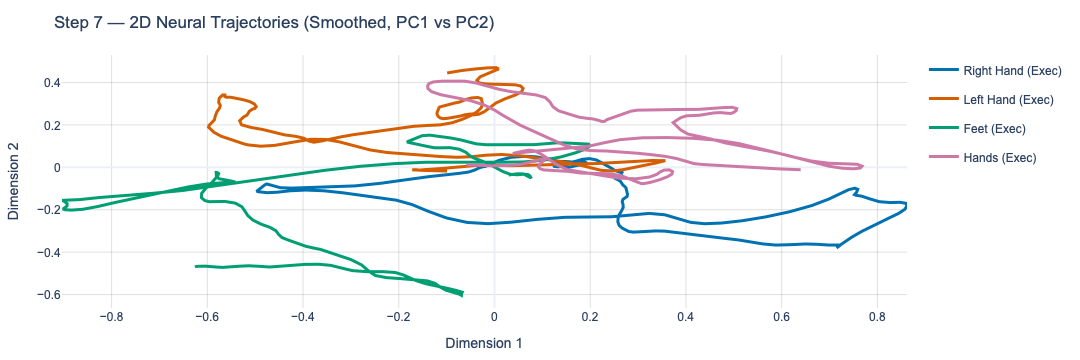

In [23]:
# 2. Create the 2D Figure (Removed SEM argument to reduce clutter)
fig_2d = plot_trajectory(
    X=traj_mean[..., :2], 
    times=time_axis,
    labels=condition_labels,
    color_map=CONDITION_COLORS,
    smooth_window=20,      # Smooths out the 160Hz high-frequency jitter
    show_markers=False,
    title='Step 7 — 2D Neural Trajectories (Smoothed, PC1 vs PC2)',
    dimensions=2,
)
fig_2d.show()


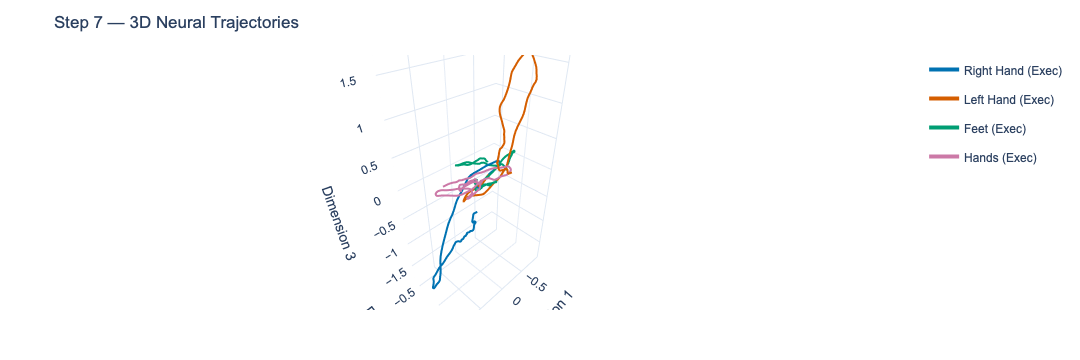

In [24]:
# 3. Create the 3D Figure
fig_3d = plot_trajectory(
    X=traj_mean[..., :3], 
    times=time_axis,
    labels=condition_labels,
    color_map=CONDITION_COLORS,
    smooth_window=20,
    show_markers=False,
    title='Step 7 — 3D Neural Trajectories',
    dimensions=3,
)
fig_3d.show()

## Step 8. Compare conditions

To quantify how distinct the neural representations of different cognitive tasks are, we calculate the geometric **trajectory separation** over time. We evaluate two different definitions of distance:
1. <span style="color: #0072B2;"><b>Euclidean (Centroid):</b></span> The raw geometric distance between the condition means in the PCA space.
2. <span style="color: #D55E00;"><b>Mahalanobis:</b></span> The distance scaled by the trial-to-trial covariance, effectively penalizing axes with high within-condition noise.

<div class="alert alert-info">
<b>💡 Interpreting Separation Metrics:</b><br>
<ul>
  <li><b>Timecourse:</b> Look for the precise moment the separation curve lifts off from zero. This is the exact latency at which the brain successfully discriminates between the two tasks!</li>
  <li><b>AUC (Area Under Curve):</b> Captures the <i>sustained</i> discriminability over the entire task window.</li>
  <li><b>Peak Separation:</b> Captures the maximum instantaneous neural divergence.</li>
</ul>
</div>

Below, we plot the full separation timecourse across the task window. Then, we extract the Peak and AUC for each individual subject, feeding them into `paired_condition_stats` to run paired t-tests (with FDR correction). This rigorously evaluates if some task pairs are statistically more separable than others!


In [16]:
from IPython.display import display
from tutorials._helpers import format_pair_keys

# ==============================================================================
# Step 8: Compare Conditions
# ==============================================================================
# 1. Compute grand-average separation timecourses for visualization
sep_timecourses = compute_separation_timecourses(
    trajectories=container_traj.X,
    conditions=np.asarray(container_traj.y).astype(int),
    methods=["centroid", "mahalanobis"]
)

In [17]:
# 2. Plot BOTH separation metrics using our new helper for readable labels!
fig_euc = plot_trajectory_separation(
    separation=format_pair_keys(sep_timecourses["centroid"], LABEL_NAMES),
    times=time_axis,
    title='Step 8 — Euclidean Separation Timecourse'
)

fig_euc.show()

In [18]:
fig_mah = plot_trajectory_separation(
    separation=format_pair_keys(sep_timecourses["mahalanobis"], LABEL_NAMES),
    times=time_axis,
    title='Step 8 — Mahalanobis Separation Timecourse'
)
fig_mah.show()

In [19]:
# ==============================================================================
# Statistical Validation & Plots
# ==============================================================================
# 3. Compute per-subject Peak and AUC scalars
df_sep = compute_separation_pair_scalars(
    trajectories=container_traj.X,
    times=time_axis,
    subjects=np.asarray(container_traj.coords['subject']),
    conditions=np.asarray(container_traj.y).astype(int),
    methods=["centroid", "mahalanobis"]
)

# Map the raw pair strings (e.g., '3_vs_4') to readable names
df_sep['pair_name'] = df_sep['pair'].apply(
    lambda x: f"{LABEL_NAMES[int(x.split('_vs_')[0])]} vs {LABEL_NAMES[int(x.split('_vs_')[1])]}"
)

In [20]:
# --- Plot Peak Separation Bar Chart ---
_peak_mask = (df_sep['method'] == 'centroid') & (df_sep['metric'] == 'peak_separation')
peak_by_pair = df_sep.loc[_peak_mask].groupby('pair_name')['value'].agg(['mean', 'std'])

fig_peak = plot_bar(
    scores=peak_by_pair['mean'],
    errors=peak_by_pair['std'],
    title='Step 8 — Peak separation per pair (centroid)',
    yaxis_title='peak distance (a.u.)',
)
fig_peak.show()

In [21]:
# --- Plot AUC Heatmap ---
_auc_mask = df_sep['metric'] == 'auc_separation'
auc_pivot = df_sep.loc[_auc_mask].pivot_table(
    index='pair_name', columns='method', values='value', aggfunc='mean'
)

fig_auc_heat = plot_heatmap(
    auc_pivot, 
    annotate=True, 
    annotation_format='.2f',
    title='Step 8 — Mean AUC per pair × method',
    xaxis_title='method', 
    yaxis_title='condition pair',
)
fig_auc_heat.show()

In [22]:
# --- Interactive Paired Stats Table ---
_auc_centroid_mask = (df_sep['method'] == 'centroid') & (df_sep['metric'] == 'auc_separation')
auc_long = df_sep.loc[_auc_centroid_mask].copy()

auc_stats = paired_condition_stats(
    scalar_df=auc_long,
    conditions=list(auc_long['pair_name'].unique()),
    condition_col="pair_name",      
    subject_col="subject",
    metric_col="metric",  
    value_col="value"
)

In [23]:
# Fallback to standard pandas styling if itables is missing
print("Paired t-tests on AUC (centroid, FDR)")
display(auc_stats.style.set_table_attributes('style="font-size: 12px"'))

#Given that we have only 5 subjects, we do not any statistical significance. 

Paired t-tests on AUC (centroid, FDR)


,metric,comparison,n,mean_diff,t,p_uncorrected,p_fdr
0,auc_separation,Left Hand (Exec) vs Right Hand (Exec) vs Left Hand (Exec) vs Hands (Exec),5,0.726339,2.312338,0.081822,0.255635
1,auc_separation,Left Hand (Exec) vs Right Hand (Exec) vs Left Hand (Exec) vs Feet (Exec),5,0.363737,2.380992,0.075907,0.255635
2,auc_separation,Left Hand (Exec) vs Right Hand (Exec) vs Right Hand (Exec) vs Hands (Exec),5,0.560486,2.483852,0.067930,0.255635
3,auc_separation,Left Hand (Exec) vs Right Hand (Exec) vs Right Hand (Exec) vs Feet (Exec),5,0.260069,1.222037,0.288782,0.393793
4,auc_separation,Left Hand (Exec) vs Right Hand (Exec) vs Hands (Exec) vs Feet (Exec),5,0.480597,1.356506,0.246449,0.378159
5,auc_separation,Left Hand (Exec) vs Hands (Exec) vs Left Hand (Exec) vs Feet (Exec),5,-0.362602,-1.509392,0.205705,0.378159
6,auc_separation,Left Hand (Exec) vs Hands (Exec) vs Right Hand (Exec) vs Hands (Exec),5,-0.165854,-1.337296,0.252106,0.378159
7,auc_separation,Left Hand (Exec) vs Hands (Exec) vs Right Hand (Exec) vs Feet (Exec),5,-0.466270,-2.112047,0.102254,0.255635
8,auc_separation,Left Hand (Exec) vs Hands (Exec) vs Hands (Exec) vs Feet (Exec),5,-0.245742,-2.154287,0.097512,0.255635
9,auc_separation,Left Hand (Exec) vs Feet (Exec) vs Right Hand (Exec) vs Hands (Exec),5,0.196748,1.377796,0.240326,0.378159


## Step 9 — Trajectory metrics & Dynamical Systems

While 3D visualizations are excellent for intuition, statistical rigor requires quantifying the geometric properties of these trajectories. We map the geometry of the neural state space to concrete cognitive interpretations using **Narrative Metrics**. 

In this step, we compute continuous time-series metrics on our group-average trajectories, visualize them as classical dynamical systems (Phase Portraits), and extract the scalars per-subject to run rigorous statistical tests.

<div class="alert alert-success">
<b>🧠 The Cognitive Interpretation Cheat Sheet:</b><br>
<ul style="margin-bottom: 0;">
  <li><b>Speed:</b> The moment-to-moment rate of change. High speed reflects rapid transitions between population states; the peak often correlates with reaction time and decision commitment.</li>
  <li><b>Phase Portraits:</b> Plotting a component's position against its own velocity. Spirals or rings mathematically prove the existence of oscillatory limit cycles in the brain.</li>
  <li><b>Path Length:</b> The total distance traveled in state space. Interpreted as the amount of representational change a condition demands (a proxy for cognitive effort).</li>
  <li><b>Tortuosity:</b> The ratio of the total path length to the straight-line displacement. High tortuosity indicates a "wandering" neural representation (e.g., due to task ambiguity).</li>
  <li><b>Dispersion (Within-Condition Spread):</b> Across-trial variability of the trajectory. Low dispersion means highly consistent neural processing.</li>
</ul>
</div>

*Note: All 13 paper-Table-2 metrics (including acceleration, curvature, and cohesion) are computed silently in the background and exported to the final CSV.*


In [24]:
from coco_pipe.viz.interactive import plot_distribution_groups
from coco_pipe.dim_reduction import trajectory_dispersion
from IPython.display import display

# ==============================================================================
# Step 9: Trajectory Metrics & Dynamical Systems
# ==============================================================================
unique_conds = DEFAULT_CONDITIONS
trial_labels = np.asarray(container_traj.y).astype(int)
times_win = np.asarray(container_traj.coords['time'])

In [25]:
# --- 1. Continuous Speed (Per-Condition Mean Timecourse) ---
speed_mean = []
speed_sem  = []
for cond in unique_conds:
    mask = trial_labels == cond
    # Compute speed across all single trials, then average
    cond_speed = trajectory_speed(container_traj.X[mask], time=times_win)
    speed_mean.append(np.nanmean(cond_speed, axis=0))
    speed_sem.append(np.nanstd(cond_speed, axis=0) / np.sqrt(max(mask.sum(), 1)))

speed_dict = {LABEL_NAMES[c]: m for c, m in zip(unique_conds, speed_mean)}

fig_speed = plot_trajectory_metric_series(
    speed_dict,
    times=times_win[1:],  # Speed loses 1 time sample due to the mathematical derivative
    title='Step 9 — Trajectory Speed per condition (paper Table 2 row 1)',
    ylabel='speed (a.u./s)',
)
fig_speed.show()


In [26]:
# --- 2. The "Comet Plot" (Color-Coded by Speed) ---
# We isolate the 'Left Hand' execution group-mean trajectory
left_idx = np.where(condition_ids == 3)[0][0]

# Speed loses 1 sample from gradient; pad with NaN to align with trajectory
_speed_vals = np.concatenate([[np.nan], speed_dict["Left Hand (Exec)"]])[np.newaxis]  # (1, n_times)
fig_comet = plot_trajectory(
    X=traj_mean[[left_idx], :, :3],
    times=times_win,
    values=_speed_vals,
    title='Dynamical State: Trajectory Color-Coded by Neural Speed',
    dimensions=3,
    show_markers=False,
    smooth_window=5
)
fig_comet.update_traces(line=dict(colorscale='Inferno', width=6))
fig_comet.show()

In [27]:
# --- 3. Dynamical Phase Portrait (PC1 Position vs Velocity) ---
pc1_position = traj_mean[..., 0] 
pc1_velocity = np.gradient(pc1_position, axis=-1)
phase_space = np.stack([pc1_position, pc1_velocity], axis=-1)

fig_phase = plot_trajectory(
    X=phase_space,
    times=times_win,
    labels=condition_labels,
    color_map=CONDITION_COLORS,
    title='Dynamical Phase Portrait (PC1 Position vs Velocity)',
    dimensions=2,
    show_markers=False,
    smooth_window=5
)
fig_phase.update_xaxes(title_text="PC1 Position (Amplitude)")
fig_phase.update_yaxes(title_text="PC1 Velocity (Rate of Change)")
fig_phase.show()

In [28]:
# --- 4. Dispersion (Within-Condition Spread) ---
spread_dict = {
    LABEL_NAMES[c]: trajectory_dispersion(container_traj.X[trial_labels == c])
    for c in unique_conds
}
fig_spread = plot_trajectory_metric_series(
    spread_dict, times=times_win,
    title='Step 9 — Within-condition spread (dispersion)',
    ylabel='within-group spread',
)
fig_spread.show()

In [29]:
# ==============================================================================
# Extract Scalar Metrics (Per-Subject) & Plot Distributions
# ==============================================================================
# Generate the full 13-metric statistical grid for the appendix
scalar_metrics = compute_per_trial_scalars(
    container_traj.X, times_win, np.asarray(container_traj.coords['subject']), trial_labels,
)
condition_scalars = compute_per_condition_scalars(
    container_traj.X, np.asarray(container_traj.coords['subject']), trial_labels,
)
scalar_metrics_all = pd.concat(
    [scalar_metrics.assign(level='trial'), condition_scalars.assign(level='condition')],
    ignore_index=True,
)
scalar_metrics_all['condition_name'] = scalar_metrics_all['condition'].map(LABEL_NAMES)

In [30]:
# --- 5. Path Length (Bar Chart) ---
path_dict = {LABEL_NAMES[c]: np.nanmean(trajectory_path_length(container_traj.X[trial_labels == c]))
             for c in unique_conds}
fig_path = plot_bar(
    pd.Series(path_dict),
    title='Step 9 — Mean path length per condition',
    yaxis_title='path length (a.u.)',
)
fig_path.show()

In [31]:
# --- 6. Distributions: Tortuosity (Violin Plots) ---
_tort_df = scalar_metrics_all[scalar_metrics_all['metric'] == 'tortuosity']
_tort_labels = [LABEL_NAMES[c] for c in DEFAULT_CONDITIONS]
_tort_groups = [_tort_df[_tort_df['condition_name'] == lbl]['value'].values for lbl in _tort_labels]
_tort_colors = [CONDITION_COLORS[c] for c in DEFAULT_CONDITIONS]
fig_tort = plot_distribution_groups(
    groups=_tort_groups,
    labels=_tort_labels,
    kind='violin',
    color=_tort_colors,
    title='Step 9 — Trajectory Tortuosity (Neural "Wandering")',
    yaxis_title='Ratio (Path Length / Displacement)',
)
fig_tort.show()

In [32]:

print("Appendix: All 13 Scalar Metrics")
display(scalar_metrics_all.head(10))


Appendix: All 13 Scalar Metrics


,subject,condition,trial,metric,value,level,condition_name
0,001,4,0.0,trajectory_length,311.921891,trial,Right Hand (Exec)
1,001,4,0.0,straight_distance,9.555158,trial,Right Hand (Exec)
2,001,4,0.0,tortuosity,32.644345,trial,Right Hand (Exec)
3,001,4,0.0,mean_speed,259.934910,trial,Right Hand (Exec)
4,001,4,0.0,max_speed,638.134820,trial,Right Hand (Exec)
5,001,4,0.0,auc_speed,309.851879,trial,Right Hand (Exec)
6,001,4,0.0,mean_curvature,0.795913,trial,Right Hand (Exec)
7,001,4,0.0,max_curvature,2.352645,trial,Right Hand (Exec)
8,001,4,0.0,mean_acceleration,1.069045,trial,Right Hand (Exec)
9,001,4,0.0,mean_turning_angle,1.096365,trial,Right Hand (Exec)


## Step 9.5 — Advanced Kinematics & State Transitions

Beyond the five narrative metrics, the *shape* of a trajectory through time
reveals **when** the brain switches representational states. Four complementary
descriptors capture different facets of that dynamics:

- **Speed Minima & Maxima.** A peak in speed indicates a rapid transition between
  states. A local minimum (where the trajectory slows down) indicates the brain
  has entered a stable *attractor state* or holding pattern.

- **Acceleration / Jerk.** Jerk is the derivative of acceleration. A sudden spike
  in jerk means the trajectory "snapped" into a new movement, often correlating
  with discrete cognitive decisions.

- **Turning Angle.** The discrete angle between successive displacement vectors. A
  spike to 90–180° means the trajectory reversed direction, signalling a hard shift
  in representational state.

- **Intra-Condition Dispersion (Spread).** A sudden increase in dispersion marks
  the exact moment where single trials diverge from one another (e.g., sensory
  processing ends and variable decision-making begins).

<div class="alert alert-info">
<b>💡 How to read these plots:</b><br>
We focus on a single condition and overlay <b>transition markers</b> as vertical dashed lines:
<ul style="margin-bottom: 0;">
  <li><span style="color:#d62728;"><b>Red</b></span> = speed minima (attractor states — the brain "settling").</li>
  <li><span style="color:#1f77b4;"><b>Blue</b></span> = jerk spikes (abrupt neural "snaps" — sudden state switches).</li>
  <li><span style="color:#9467bd;"><b>Purple</b></span> = dispersion jumps (the moment trials begin diverging from one another).</li>
</ul>
</div>


In [33]:
from scipy.signal import find_peaks
from coco_pipe.dim_reduction import trajectory_jerk, trajectory_turning_angle

# ── Pick one condition to analyse ────────────────────────────────────────────
# Identify "Hands + Feet Exec" from LABEL_NAMES (value contains "Exec" and "Feet")
focus_cond = next(
    (c for c, name in LABEL_NAMES.items() if 'exec' in name.lower() and 'feet' in name.lower()),
    unique_conds[-1],  # fallback: last condition
)
focus_name  = LABEL_NAMES[focus_cond]
focus_mask  = trial_labels == focus_cond
focus_trajs = container_traj.X[focus_mask, :, :3]   # shape (n_trials, n_times, 3)
print(f"Analysing condition '{focus_name}' — {focus_mask.sum()} trials")

# ── Time axes ────────────────────────────────────────────────────────────────
dt     = float(np.diff(times_win).mean())
t_full = times_win                        # length n_times

# ── 1. Speed (condition-mean) ────────────────────────────────────────────────
speed_trials = trajectory_speed(focus_trajs, time=times_win)   # (n_trials, n_times-1)
speed_curve  = np.nanmean(speed_trials, axis=0)                 # (n_times-1,)
t_speed      = times_win[:-1]

# ── 2. Jerk (condition-mean) ─────────────────────────────────────────────────
jerk_trials = trajectory_jerk(focus_trajs, dt=dt)   # (n_trials, n_times)
jerk_curve  = np.nanmean(jerk_trials, axis=0)        # (n_times,)
t_jerk      = t_full

# ── 3. Turning angle (condition-mean) ────────────────────────────────────────
angle_trials = trajectory_turning_angle(focus_trajs)  # (n_trials, n_times-2)
angle_curve  = np.nanmean(np.degrees(angle_trials), axis=0)
t_angle      = times_win[1:-1]

# ── 4. Intra-condition dispersion ────────────────────────────────────────────
disp_curve = trajectory_dispersion(focus_trajs)   # (n_times,)
t_disp     = t_full

# ── Find transition markers ───────────────────────────────────────────────────
speed_min_idx, _      = find_peaks(-speed_curve, distance=5)
jerk_max_idx, _       = find_peaks(jerk_curve, distance=5, height=np.percentile(jerk_curve, 70))
disp_deriv            = np.gradient(disp_curve, dt)
disp_deriv_max_idx, _ = find_peaks(disp_deriv, distance=5, height=np.percentile(disp_deriv, 70))

print(f"Speed minima at t   = {t_speed[speed_min_idx].round(3).tolist()}")
print(f"Jerk spikes at t    = {t_jerk[jerk_max_idx].round(3).tolist()}")
print(f"Dispersion jumps at t = {t_disp[disp_deriv_max_idx].round(3).tolist()}")

# ── Plot each timecourse with transition markers ──────────────────────────────
metrics_for_plot = {
    "Speed":                     (speed_curve, t_speed),
    "Jerk":                      (jerk_curve,  t_jerk),
    "Turning Angle (°)":         (angle_curve, t_angle),
    "Intra-Condition Dispersion": (disp_curve,  t_disp),
}
ylabels = {
    "Speed":                      "speed (a.u./s)",
    "Jerk":                       "jerk (a.u./s³)",
    "Turning Angle (°)":          "angle (°)",
    "Intra-Condition Dispersion":  "spread (a.u.)",
}

kin_figs = {}
for metric_label, (curve, t_ax) in metrics_for_plot.items():
    n   = min(len(t_ax), len(curve))
    fig = plot_trajectory_metric_series(
        {focus_name: curve[:n]},
        times=t_ax[:n],
        title=f"Step 9.5 — {metric_label} ({focus_name})",
        ylabel=ylabels[metric_label],
    )
    if metric_label == "Speed":
        for idx in speed_min_idx:
            if idx < len(t_speed):
                fig.add_vline(x=float(t_speed[idx]), line_dash="dash", line_color="red",
                              line_width=1.5, annotation_text="slow", annotation_position="top right")
    if metric_label == "Jerk":
        for idx in jerk_max_idx:
            if idx < len(t_jerk):
                fig.add_vline(x=float(t_jerk[idx]), line_dash="dash", line_color="#1f77b4",
                              line_width=1.5, annotation_text="snap", annotation_position="top right")
    if metric_label == "Intra-Condition Dispersion":
        for idx in disp_deriv_max_idx:
            if idx < len(t_disp):
                fig.add_vline(x=float(t_disp[idx]), line_dash="dash", line_color="#9467bd",
                              line_width=1.5, annotation_text="diverge", annotation_position="top right")
    kin_figs[metric_label] = fig
    fig.show()


Analysing condition 'Feet (Exec)' — 115 trials
Speed minima at t   = [-0.169, -0.106, -0.075, -0.038, -0.006, 0.062, 0.119, 0.175, 0.206, 0.262, 0.325, 0.388, 0.419, 0.469, 0.506, 0.538, 0.569, 0.612, 0.681, 0.738, 0.781, 0.819, 0.869, 0.906, 0.95, 0.988]
Jerk spikes at t    = [-0.181, -0.138, -0.094, -0.025, 0.05, 0.1, 0.131, 0.169, 0.2, 0.238, 0.3, 0.338, 0.375, 0.45, 0.581, 0.812, 0.844, 0.9]
Dispersion jumps at t = [-0.1, -0.038, 0.006, 0.056, 0.088, 0.119, 0.256, 0.3, 0.475, 0.538, 0.569, 0.644, 0.969]


## Step 10 — Validate (Quality Control)

Before drawing cognitive conclusions from lower-dimensional neural trajectories, we must rigorously validate that the dimensionality reduction did not destroy the true geometry of the neural state space, and that our condition separations are not merely statistical noise.

<div class="alert alert-warning">
<b>⚠️ Validation Metrics:</b><br>
<ul>
  <li><b>Trustworthiness:</b> Measures if the PCA artificially crushed distant high-dimensional states close together in 3D (false neighbors). Scores > 0.85 are considered excellent.</li>
  <li><b>Continuity:</b> Measures if the PCA artificially tore close high-dimensional neighbors far apart in 3D.</li>
  <li><b>Shepard Diagram:</b> A scatter plot of original 64D distances vs embedded 3D distances. A tight diagonal line indicates perfect distance preservation.</li>
  <li><b>Permutation Null (Separation AUC):</b> We shuffle the condition labels thousands of times to build a null distribution of trajectory separation. If our observed separation AUC is higher than the 95th percentile of the null, the neural separation is statistically significant ($p < 0.05$).</li>
</ul>
</div>


In [34]:
# ==============================================================================
# Step 10: Validate (Quality Control)
# ==============================================================================
# 1. Score the shared embedding (Trustworthiness & Continuity)
# We subsample to max 1500 observations to keep the distance computations fast
score_n = min(1500, shared_scores.shape[0])
score_idx = rng.choice(shared_scores.shape[0], size=score_n, replace=False)

score_payload = shared_reducer.score(
    X_emb=shared_scores[score_idx, :3],        # The visual 3D space
    X=container_plot_pooled.X[score_idx],      # The true 64D sensor space
    n_neighbors=min(20, score_n - 2),
    metrics=['trustworthiness', 'continuity'],
)
metrics_summary = score_payload.get('metrics', {})
print('Embedding Quality:', metrics_summary)

Embedding Quality: {'trustworthiness': 0.7495537257570603, 'continuity': 0.8019945332879664}


In [35]:
# ==============================================================================
# 2. Shepard Diagram (Distance Preservation)
# ==============================================================================
# We restrict sample_size=300 to prevent the massive 2D contour trace from 
# serializing ~19MB of data and freezing the web browser during HTML export!
fig_shepard = plot_shepard_diagram(
    X_orig=container_plot_pooled.X[score_idx],
    X_emb=shared_scores[score_idx, :3],
    sample_size=300,
    title='Step 10 — Shepard diagram (3D vs 64D)',
)
fig_shepard.show()

In [36]:
# ==============================================================================
# 3. Statistical Significance: Permutation Null on Separation AUC
# ==============================================================================
# We test a complex contrast: Unilateral (Left/Right) vs Bilateral (Hands/Feet)
obs_auc, null_auc = permutation_null_separation_auc(
    trajectories=container_traj.X,
    times=times_win,
    conditions=np.asarray(container_traj.y).astype(int),
    group_a=[3, 4],   # Unilateral Exec
    group_b=[7, 8],   # Bilateral Exec
    n_perm=200,
    rng=rng,
    window=(0.0, 1.5), # Only evaluate separation during the active task!
)

In [37]:
# Calculate exact empirical p-value (adding +1 for the observed permutation itself)
p_value = float((np.sum(null_auc >= obs_auc) + 1) / (len(null_auc) + 1))
print(f'Observed AUC = {obs_auc:.3f}; Null p-value = {p_value:.3f}')

# Plot the Null Distribution vs our Observed Statistic
_null_frame = pd.DataFrame({
    "Model": ["PCA Trajectory"],
    "Metric": ["AUC"],
    "Observed": [obs_auc],
    "NullLower": [float(np.percentile(null_auc, 2.5))],
    "NullUpper": [float(np.percentile(null_auc, 97.5))],
})
fig_null = plot_null_interval_summary(
    _null_frame,
    title=f'Step 10 — Permutation Null (Unilateral vs Bilateral AUC)<br>Empirical p-value: {p_value:.3f}',
)
fig_null.show()

Observed AUC = 0.569; Null p-value = 0.547


## Bonus Step — Export Interactive HTML Dashboard & Artifacts

The core philosophy of `coco-pipe` is that neural data analysis should be **interactive** and **sharable**. Jupyter Notebooks are fantastic for exploratory coding, but they are heavy, require environments, and are difficult to present to clinical collaborators or Principal Investigators.

In this final step, we use `coco-pipe`'s HTML Report Builder to bundle all the interactive Plotly figures and tables we generated into a single, standalone HTML dashboard. This file requires zero dependencies and can be opened on any laptop or phone. 

Finally, we save our trained PCA models (`DimReduction` objects) and extracted trajectory matrices (`DataContainer` objects) as `.pkl` artifacts. This allows our advanced BCI Decoding tutorials to load the exact state-space representations we discovered here without having to re-run the computationally expensive preprocessing pipelines!


In [38]:
from coco_pipe.report import Report, Section, PlotlyElement, InteractiveTableElement

# ==============================================================================
# 1. Initialize the Standalone Report
# ==============================================================================
report = Report(
    title="Neural Trajectories: EEGBCI Motor Imagery",
    asset_urls="inline",
)

# ==============================================================================
# 2. Build the Sections
# ==============================================================================
# --- Section A: Visualizing Trajectories ---
sec_viz = Section("3D Neural Trajectories", icon="play")
sec_viz.add_markdown("Group-mean neural trajectories for physical execution tasks. Notice how the trajectories start clustered at the origin before branching out in response to the stimulus.")
sec_viz.add_element(PlotlyElement(fig_3d, height="600px"))
sec_viz.add_element(PlotlyElement(fig_2d, height="500px"))
report.add_section(sec_viz)

# --- Section B: Dynamical Systems ---
sec_dyn = Section("Dynamical Systems & State Space", icon="activity")
sec_dyn.add_markdown("By plotting PC1 Position vs Velocity, we can identify oscillatory limit cycles in the brain. The 'Comet Plot' highlights moments of rapid cognitive transition.")
sec_dyn.add_element(PlotlyElement(fig_comet, height="600px"))
sec_dyn.add_element(PlotlyElement(fig_phase, height="500px"))
sec_dyn.add_element(PlotlyElement(fig_speed, height="450px"))
report.add_section(sec_dyn)

# --- Section C: Statistics & Quality Control ---
sec_stats = Section("Statistics & Quality Control", icon="check-square")
sec_stats.add_markdown(
    f"**Manifold Quality:** Trustworthiness = {metrics_summary.get('trustworthiness', float('nan')):.3f}, "
    f"Continuity = {metrics_summary.get('continuity', float('nan')):.3f}.<br>"
    f"**Separation Null:** Empirical p-value = {p_value:.3f}."
)
sec_stats.add_element(PlotlyElement(fig_path, height="450px"))
sec_stats.add_element(PlotlyElement(fig_tort, height="450px"))
sec_stats.add_element(PlotlyElement(fig_shepard, height="420px"))
sec_stats.add_element(PlotlyElement(fig_null, height="420px"))

# Add the massive 13-metric statistical table as a clean, searchable element
sec_stats.add_element(
    InteractiveTableElement(
        scalar_metrics_all,
        title='Appendix: All 13 Scalar Metrics (Single-Trial & Condition Level)',
        selector_columns=['level', 'metric', 'condition_name'],
    )
)
report.add_section(sec_stats)

# ==============================================================================
# 3. Export to Disk
# ==============================================================================
# A. Save the HTML Report
report_path = ROOT / "report_tutorial_eegbci.html"
report.save(report_path)
print(f"✅ HTML Dashboard successfully generated at: {report_path}")
print(f"   -> Double click this file in your browser to explore the interactive report!")

# B. Save the mathematical artifacts for downstream BCI Decoding tutorials
save_artifacts(
    artifacts_dir=ARTIFACTS_DIR,
    shared_reducer=shared_reducer,
    trajectory_container=container_traj,
    per_subject_reducers=per_subject_reducers,
    scalar_metrics=scalar_metrics_all,
    continuous_metrics=pd.DataFrame(), # Can be populated if exporting raw timecourses to CSV
    separation_pair_scalars=df_sep, 
)
print(f"Trained PCA models and data matrices exported to: {ARTIFACTS_DIR}")


✅ HTML Dashboard successfully generated at: outputs/tutorial_eegbci/report_tutorial_eegbci.html
   -> Double click this file in your browser to explore the interactive report!
Saved artifacts → outputs/tutorial_eegbci/artifacts
Trained PCA models and data matrices exported to: outputs/tutorial_eegbci/artifacts


## Paper Composite — 5-Panel Figure

Assembles the 5 panels of the manuscript composite into one Plotly figure and
writes it as PNG, SVG, and a self-contained HTML. The same layout is regenerated
at 109 subjects by `analysis/analysis_paper_eegbci_109.py`.

| Panel | Content |
|-------|---------|
| **A** | Scree plot — explained variance per PC |
| **B** | Trial-mean PC1–PC2 scatter (one dot per trial) |
| **C** | 3D group-mean trajectories (PC1–PC2–PC3) |
| **D** | Speed timecourse per condition ± SEM |
| **E** | Separation timecourse (centroid + Mahalanobis, overlaid) |


In [39]:
from plotly.subplots import make_subplots

fig_paper = make_subplots(
    rows=2, cols=3,
    specs=[
        [{'type': 'xy'}, {'type': 'xy'}, {'type': 'scene'}],
        [{'type': 'xy', 'colspan': 2}, None, {'type': 'xy'}],
    ],
    subplot_titles=(
        'A — Scree', 'B — Trial-mean PC1–PC2', 'C — 3D trajectories',
        'D — Speed timecourse', 'E — Separation (centroid + Mahalanobis)',
    ),
    horizontal_spacing=0.08, vertical_spacing=0.12,
)

# Panel A — scree (first 10 components)
fig_paper.add_trace(
    go.Bar(x=[f'PC{i+1}' for i in range(len(evr))], y=evr, name='Var.', showlegend=False),
    row=1, col=1,
)

# Panel B — trial-mean PC1–PC2 scatter coloured by condition
trial_means_2d = container_traj.X[..., :2].mean(axis=1)  # (n_trials, 2)
for cond in unique_conds:
    mask = trial_labels == cond
    fig_paper.add_trace(
        go.Scatter(
            x=trial_means_2d[mask, 0], y=trial_means_2d[mask, 1],
            mode='markers',
            marker=dict(color=CONDITION_COLORS[cond], size=5, opacity=0.6),
            name=LABEL_NAMES[cond], legendgroup=LABEL_NAMES[cond],
        ),
        row=1, col=2,
    )

# Panel C — 3D group-mean trajectories
for i, cond in enumerate(unique_conds):
    traj = traj_mean[i, :, :3]   # (n_times, 3)
    fig_paper.add_trace(
        go.Scatter3d(
            x=traj[:, 0], y=traj[:, 1], z=traj[:, 2],
            mode='lines',
            line=dict(color=CONDITION_COLORS[cond], width=5),
            name=LABEL_NAMES[cond], legendgroup=LABEL_NAMES[cond],
            showlegend=False,
        ),
        row=1, col=3,
    )

# Panel D — speed timecourse with SEM
for cond, m, s in zip(unique_conds, speed_mean, speed_sem):
    fig_paper.add_trace(
        go.Scatter(
            x=times_win[1:], y=m,
            mode='lines',
            line=dict(color=CONDITION_COLORS[cond], width=2),
            error_y=dict(type='data', array=s, visible=True, thickness=0.5),
            name=LABEL_NAMES[cond], legendgroup=LABEL_NAMES[cond],
            showlegend=False,
        ),
        row=2, col=1,
    )

# Panel E — separation timecourses (centroid solid, Mahalanobis dashed)
for method, dash in [('centroid', 'solid'), ('mahalanobis', 'dash')]:
    for (a, b), curve in sep_timecourses[method].items():
        fig_paper.add_trace(
            go.Scatter(
                x=time_axis, y=curve, mode='lines',
                line=dict(width=2, dash=dash),
                name=f'{LABEL_NAMES[a]} vs {LABEL_NAMES[b]} ({method})',
            ),
            row=2, col=3,
        )

fig_paper.update_layout(
    title=f'PCA Neural Trajectory Analysis — EEGBCI ({len(SUBJECTS)} subjects)',
    height=820, width=1400,
    template='plotly_white',
)

# Static exports (PNG always renders; SVG for vector publishing)
fig_paper.write_image(str(ROOT / 'paper_figure.png'), scale=2)
fig_paper.write_image(str(ROOT / 'paper_figure.svg'))
fig_paper.write_html(str(ROOT / 'paper_figure.html'), include_plotlyjs='inline')
print('Saved paper_figure.{png,svg,html} to', ROOT)
fig_paper


Saved paper_figure.{png,svg,html} to outputs/tutorial_eegbci
